In [1]:
# ============================================================
# SECTION 0 — Setup
# ============================================================

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

YEAR = "2013"

settings = importlib.import_module(f"config.settings_{YEAR}")
for k in dir(settings):
    if not k.startswith("_"):
        globals()[k] = getattr(settings, k)

from src.pride_comparison_utils import (
    load_dsn_doppler_file,
    load_pride_scint_file,
    get_common_days,
    build_dsn_pride_binned_comparison,
    build_daily_dsn_pride_summary,
    compute_signal_correlations,
    compute_xcorr_summary,
)

from src.plot_utils import (
    plot_xcorr_summary,
    plot_xcorr_day,
)

debug = True
sav_file = False

OUTPUT_DIR = PROJECT_ROOT / "outputs" / YEAR

print("YEAR:", YEAR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

YEAR: 2013
PROJECT_ROOT: /mnt/data/jhub/16-VenusExpres/dsn_multi_year
OUTPUT_DIR: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2013


In [2]:
# ============================================================
# SECTION 1 — Load DSN and PRIDE data
# ============================================================

DATA_ROOT = PROJECT_ROOT.parent

DSN_FILE = DATA_ROOT / "dataByYear" / f"data_{YEAR}.txt"
PRIDE_FILE = DATA_ROOT / "scintdataByYear" / f"scint_{YEAR}.txt"

print("DSN_FILE:", DSN_FILE)
print("PRIDE_FILE:", PRIDE_FILE)
print("DSN exists:", DSN_FILE.exists())
print("PRIDE exists:", PRIDE_FILE.exists())

dsn_df = load_dsn_doppler_file(DSN_FILE)
pride_df = load_pride_scint_file(PRIDE_FILE)

print("DSN rows:", len(dsn_df))
print("DSN range:", dsn_df.index.min(), "→", dsn_df.index.max())

print("PRIDE rows:", len(pride_df))
print("PRIDE range:", pride_df.index.min(), "→", pride_df.index.max())

display(dsn_df.head())
display(pride_df.head())

DSN_FILE: /mnt/data/jhub/16-VenusExpres/dataByYear/data_2013.txt
PRIDE_FILE: /mnt/data/jhub/16-VenusExpres/scintdataByYear/scint_2013.txt
DSN exists: True
PRIDE exists: True
DSN rows: 792142
DSN range: 2013-01-01 08:07:57.806000 → 2013-12-30 16:56:00.686000
PRIDE rows: 55
PRIDE range: 2013-01-17 08:00:00 → 2013-12-29 11:20:00


,mode,timestamp,valid,doppler,sc,lat,lon,gs,aa,elev,altitude,tropo,ab
UTC_time,,,,,,,,,,,,,
2013-01-01 08:07:57.806,39,23011.338491,1.0,-0.005213,VEX,-51.511,319.165,69,0.0,18.144,3.872292e+07,0.049,0.0
2013-01-01 08:08:07.829,39,23011.338607,1.0,-0.003499,VEX,-51.528,319.165,69,0.0,18.163,3.874389e+07,0.049,0.0
2013-01-01 08:08:17.765,39,23011.338722,1.0,-0.001393,VEX,-51.546,319.165,69,0.0,18.182,3.876485e+07,0.049,0.0
2013-01-01 08:08:27.787,39,23011.338838,1.0,-0.002154,VEX,-51.563,319.165,69,0.0,18.201,3.878580e+07,0.048,0.0
2013-01-01 08:08:37.810,39,23011.338954,1.0,-0.002389,VEX,-51.581,319.166,69,0.0,18.220,3.880674e+07,0.048,0.0


,Scint_rad,Slope,Slope_err,PeakSPD,TEC_Down,TEC_Up,TEC_Total,Dnoise
UTC,,,,,,,,
2013-01-17 08:00:00,0.407,-2.432,0.12,2.89,47.8,38.0,917.0,3.81
2013-01-17 08:20:00,0.354,-2.432,0.12,2.89,43.9,36.8,917.0,3.85
2013-01-17 08:40:00,0.284,-2.432,0.12,2.89,40.4,36.2,917.0,3.74
2013-01-17 09:00:00,0.261,-2.432,0.12,2.89,37.2,36.2,917.0,3.67
2013-01-17 09:20:00,0.389,-2.432,0.12,2.89,34.7,36.2,917.0,4.28


In [3]:
# ============================================================
# SECTION 2 — Find common observing days
# ============================================================

common_days = get_common_days(dsn_df, pride_df)

print("Common days:", len(common_days))
display(pd.DataFrame({"day": common_days}))

Common days: 10


,day
0,2013-01-17
1,2013-04-22
2,2013-11-11
3,2013-11-14
4,2013-11-21
5,2013-11-28
6,2013-12-18
7,2013-12-27
8,2013-12-28
9,2013-12-29


In [4]:
# ============================================================
# SECTION 3 — Build 20-min binned DSN/PRIDE comparison
# ============================================================

binned_df = build_dsn_pride_binned_comparison(
    dsn_df,
    pride_df,
    common_days=common_days,
    bin_freq="20min",
    f_low_hz=3e-3,
    f_high_hz=0.1,
    detrend_poly_order=4,
    min_samples=16,
)

print("Common 20-min bins:", len(binned_df))
display(binned_df.head())

Common 20-min bins: 35


,dsn_sigma_phi_rad,n_dsn_samples,pride_scint_rad,day
2013-01-17 08:40:00,0.409559,120,0.284,2013-01-17
2013-01-17 09:00:00,0.334795,120,0.261,2013-01-17
2013-01-17 09:20:00,0.333966,120,0.389,2013-01-17
2013-04-22 09:20:00,1.344992,120,0.955,2013-04-22
2013-04-22 09:40:00,1.036481,120,0.915,2013-04-22


In [5]:
# ============================================================
# SECTION 4 — Daily summary and correlations
# ============================================================

daily_df = build_daily_dsn_pride_summary(binned_df)

print("Daily overlap rows:", len(daily_df))
display(daily_df.head())

print("Binned correlation:")
print(compute_signal_correlations(binned_df))

print("\nDaily correlation:")
print(compute_signal_correlations(daily_df))

Daily overlap rows: 9


,day,dsn_sigma_phi_rad,pride_scint_rad,n_bins
0,2013-01-17,0.359440,0.311333,3
1,2013-04-22,1.303437,0.986333,6
2,2013-11-11,0.237428,0.229000,6
3,2013-11-14,0.130837,0.174000,4
4,2013-11-21,0.435949,0.283200,5


Binned correlation:
{'n': 35, 'pearson_r': np.float64(0.9689277010316003), 'pearson_p': np.float64(1.352848215777565e-21), 'spearman_rho': np.float64(0.831372549019608), 'spearman_p': np.float64(6.227915060323732e-10), 'kendall_tau': np.float64(0.6504201680672269), 'kendall_p': np.float64(3.886033566680042e-08)}

Daily correlation:
{'n': 9, 'pearson_r': np.float64(0.9894842706248927), 'pearson_p': np.float64(3.886212056789147e-07), 'spearman_rho': np.float64(0.9666666666666667), 'spearman_p': np.float64(2.155031274835775e-05), 'kendall_tau': np.float64(0.8888888888888888), 'kendall_p': np.float64(0.00024250440917107584)}


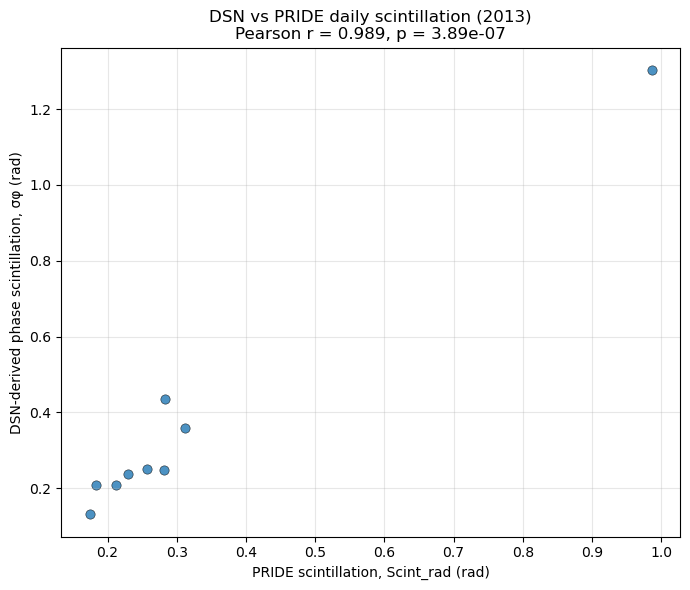

Raw daily rows: 9
Quality-controlled daily rows: 9


In [6]:
# ============================================================
# SECTION 5 — Daily scatter comparison, quality-controlled
# ============================================================

MAX_VALID_DSN_SIGMA = 2.0

daily_plot_bins = binned_df[
    (binned_df["dsn_sigma_phi_rad"] > 0) &
    (binned_df["dsn_sigma_phi_rad"] <= MAX_VALID_DSN_SIGMA) &
    (binned_df["pride_scint_rad"] > 0)
].copy()

daily_plot_df = build_daily_dsn_pride_summary(daily_plot_bins)

stats = compute_signal_correlations(daily_plot_df)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    daily_plot_df["pride_scint_rad"],
    daily_plot_df["dsn_sigma_phi_rad"],
    s=45,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.4,
)

ax.set_xlabel("PRIDE scintillation, Scint_rad (rad)")
ax.set_ylabel("DSN-derived phase scintillation, σφ (rad)")
ax.set_title(
    f"DSN vs PRIDE daily scintillation ({YEAR})\n"
    f"Pearson r = {stats['pearson_r']:.3f}, p = {stats['pearson_p']:.2e}"
)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Raw daily rows:", len(daily_df))
print("Quality-controlled daily rows:", len(daily_plot_df))

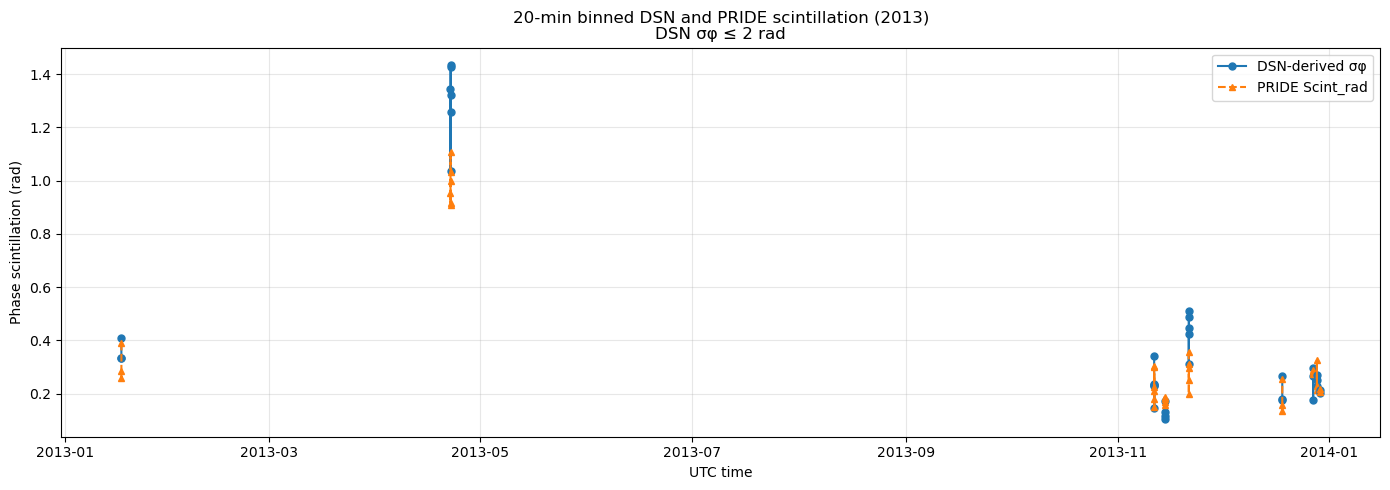

In [7]:
# ============================================================
# SECTION 6 — Final paper-quality time-series plot
# ============================================================

MAX_VALID_DSN_SIGMA = 2.0

plot_df = binned_df[
    (binned_df["dsn_sigma_phi_rad"] > 0) &
    (binned_df["dsn_sigma_phi_rad"] <= MAX_VALID_DSN_SIGMA) &
    (binned_df["pride_scint_rad"] > 0)
].copy().sort_index()

DSN_COLOR = "tab:blue"
PRIDE_COLOR = "tab:orange"

fig, ax = plt.subplots(figsize=(14, 5))

for i, (day, sub) in enumerate(plot_df.groupby("day")):

    ax.plot(
        sub.index,
        sub["dsn_sigma_phi_rad"],
        marker="o",
        linestyle="-",
        linewidth=1.5,
        markersize=5,
        color=DSN_COLOR,
        label="DSN-derived σφ" if i == 0 else None,
    )

    ax.plot(
        sub.index,
        sub["pride_scint_rad"],
        marker="^",
        linestyle="--",
        linewidth=1.5,
        markersize=5,
        color=PRIDE_COLOR,
        label="PRIDE Scint_rad" if i == 0 else None,
    )

ax.set_ylabel("Phase scintillation (rad)")
ax.set_xlabel("UTC time")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")

ax.set_title(
    f"20-min binned DSN and PRIDE scintillation ({YEAR})\n"
    f"DSN σφ ≤ {MAX_VALID_DSN_SIGMA:g} rad"
)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# SECTION 6.1 — Interactive single-day DSN/PRIDE viewer
# ============================================================

import ipywidgets as widgets
from IPython.display import display

plot_df = binned_df.copy().sort_index()
days = sorted(plot_df["day"].unique())

def plot_one_day(day):
    day = pd.to_datetime(day)
    sub = plot_df[plot_df["day"] == day]

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        sub.index,
        sub["dsn_sigma_phi_rad"],
        marker="o",
        linestyle="-",
        linewidth=1.8,
        label="DSN-derived σφ",
    )

    ax.plot(
        sub.index,
        sub["pride_scint_rad"],
        marker="^",
        linestyle="--",
        linewidth=1.8,
        label="PRIDE Scint_rad",
    )

    ax.set_title(f"20-min scintillation comparison — {day.date()}")
    ax.set_xlabel("UTC time")
    ax.set_ylabel("Phase scintillation (rad)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()

day_picker = widgets.Dropdown(
    options=[pd.to_datetime(d).date() for d in days],
    description="Day:",
    layout=widgets.Layout(width="250px"),
)

out = widgets.interactive_output(
    plot_one_day,
    {"day": day_picker},
)

display(widgets.HBox([day_picker]), out)

Output()

In [9]:
# ============================================================
# SECTION 7 — Per-day cross-correlation summary
# ============================================================

BIN_MINUTES = 20
MIN_BINS_FOR_XCORR = 4

xcorr_df = compute_xcorr_summary(
    binned_df,
    bin_minutes=BIN_MINUTES,
    min_bins=MIN_BINS_FOR_XCORR,
)

display(xcorr_df)

valid_xcorr = xcorr_df[xcorr_df["used_for_summary"]].copy()

print("Days with enough bins:", len(valid_xcorr), "of", len(xcorr_df))
print("Median best lag (min):", valid_xcorr["best_lag_minutes"].median())
print("Median best corr:", valid_xcorr["best_corr"].median())
print("Median zero-lag corr:", valid_xcorr["zero_lag_corr"].median())

,day,n_bins,used_for_summary,best_lag_bins,best_lag_minutes,best_corr,zero_lag_corr
0,2013-01-17,3,False,NaN,NaN,NaN,NaN
1,2013-04-22,6,True,1.0,20.0,0.497014,0.178081
2,2013-11-11,6,True,0.0,0.0,0.773790,0.773790
3,2013-11-14,4,True,-2.0,-40.0,0.594377,0.554979
4,2013-11-21,5,True,-1.0,-20.0,0.518273,-0.158897
5,2013-12-18,3,False,NaN,NaN,NaN,NaN
6,2013-12-27,3,False,NaN,NaN,NaN,NaN
7,2013-12-28,3,False,NaN,NaN,NaN,NaN
8,2013-12-29,2,False,NaN,NaN,NaN,NaN


Days with enough bins: 4 of 9
Median best lag (min): -10.0
Median best corr: 0.5563250556233146
Median zero-lag corr: 0.36652990477994934


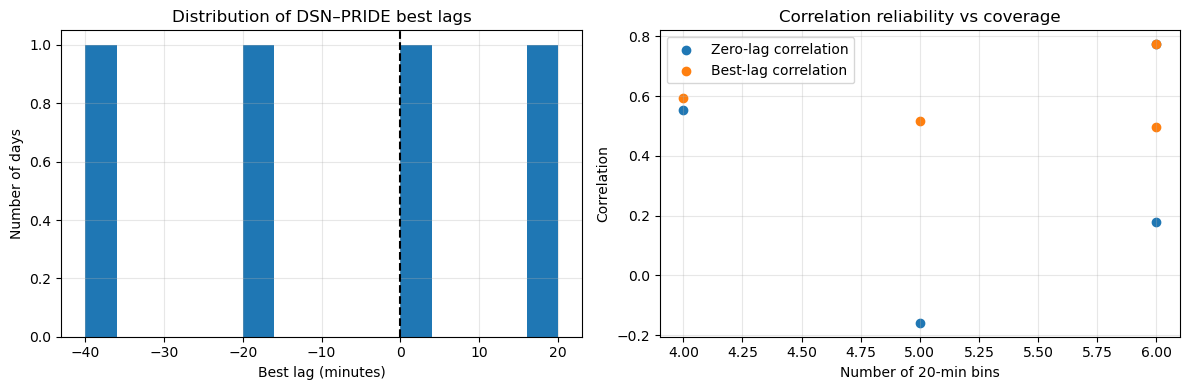

In [10]:
# ============================================================
# SECTION 7.1 — Cross-correlation summary plots
# ============================================================

fig, axes = plot_xcorr_summary(xcorr_df)
plt.show()

In [11]:
# ============================================================
# SECTION 7.2 — Interactive cross-correlation viewer
# ============================================================

import ipywidgets as widgets
from IPython.display import display

day_picker = widgets.Dropdown(
    options=[pd.to_datetime(d).date() for d in sorted(binned_df["day"].unique())],
    description="Day:",
)

def show_xcorr(day):
    fig, ax = plot_xcorr_day(
        binned_df,
        day,
        bin_minutes=BIN_MINUTES,
    )
    plt.show()

out = widgets.interactive_output(
    show_xcorr,
    {"day": day_picker},
)

display(day_picker, out)

Dropdown(description='Day:', options=(datetime.date(2013, 1, 17), datetime.date(2013, 4, 22), datetime.date(20…

Output()

In [12]:
print("All days:", len(xcorr_df))
print("Median best lag:", xcorr_df["best_lag_minutes"].median())
print("IQR best lag:",
      xcorr_df["best_lag_minutes"].quantile(0.25),
      "to",
      xcorr_df["best_lag_minutes"].quantile(0.75))

print("Median best corr:", xcorr_df["best_corr"].median())
print("Median zero-lag corr:", xcorr_df["zero_lag_corr"].median())

print("Fraction with |best lag| <= 20 min:",
      (xcorr_df["best_lag_minutes"].abs() <= 20).mean())

print("Fraction with positive zero-lag corr:",
      (xcorr_df["zero_lag_corr"] > 0).mean())

All days: 9
Median best lag: -10.0
IQR best lag: -25.0 to 5.0
Median best corr: 0.5563250556233146
Median zero-lag corr: 0.36652990477994934
Fraction with |best lag| <= 20 min: 0.3333333333333333
Fraction with positive zero-lag corr: 0.3333333333333333


In [13]:
print(plot_df[["dsn_sigma_phi_rad", "pride_scint_rad"]].describe())

       dsn_sigma_phi_rad  pride_scint_rad
count          35.000000        35.000000
mean            0.444649         0.369286
std             0.412243         0.292323
min             0.105029         0.137000
25%             0.209575         0.203500
50%             0.267659         0.261000
75%             0.435396         0.317500
max             1.432948         1.106000


All bins: 35
Figure bins: 35
Excluded from scatter: 0


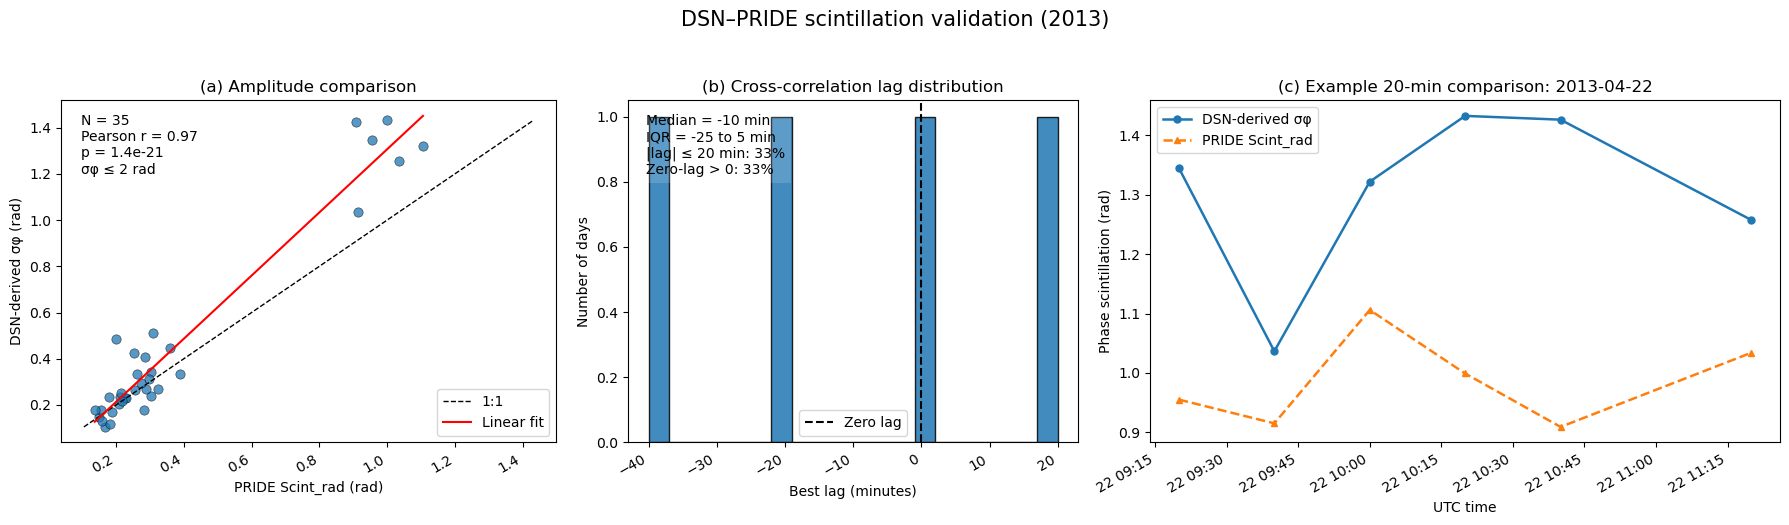

In [14]:
# ============================================================
# SECTION 8 — Final DSN/PRIDE validation figure
# ============================================================

EXAMPLE_DAY = pd.to_datetime("2014-11-14")   # change if needed
FIG_FILE = OUTPUT_DIR / f"dsn_pride_validation_summary_{YEAR}.png"

plot_df = binned_df.copy().sort_index()
xcorr_plot = xcorr_df.copy()

# ------------------------------
# Figure-only quality cut
# Keeps raw binned_df unchanged
# ------------------------------
MAX_VALID_DSN_SIGMA = 2.0

figure_df = plot_df[
    (plot_df["dsn_sigma_phi_rad"] > 0) &
    (plot_df["dsn_sigma_phi_rad"] <= MAX_VALID_DSN_SIGMA) &
    (plot_df["pride_scint_rad"] > 0)
].copy()

print("All bins:", len(plot_df))
print("Figure bins:", len(figure_df))
print("Excluded from scatter:", len(plot_df) - len(figure_df))

# ------------------------------
# Stats
# ------------------------------
stats = compute_signal_correlations(figure_df)

median_lag = xcorr_plot["best_lag_minutes"].median()
q25_lag = xcorr_plot["best_lag_minutes"].quantile(0.25)
q75_lag = xcorr_plot["best_lag_minutes"].quantile(0.75)

frac_near_zero = (xcorr_plot["best_lag_minutes"].abs() <= 20).mean()
frac_positive_zero = (xcorr_plot["zero_lag_corr"] > 0).mean()

# ------------------------------
# Example day
# ------------------------------
example_sub = plot_df[plot_df["day"] == EXAMPLE_DAY].copy()

if example_sub.empty:
    EXAMPLE_DAY = plot_df.groupby("day").size().idxmax()
    example_sub = plot_df[plot_df["day"] == EXAMPLE_DAY].copy()

# ------------------------------
# Figure
# ------------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5),
    gridspec_kw={"width_ratios": [1.1, 1.0, 1.4]}
)

ax0, ax1, ax2 = axes

# ============================================================
# Panel A — Scatter comparison
# ============================================================

x = figure_df["pride_scint_rad"]
y = figure_df["dsn_sigma_phi_rad"]

ax0.scatter(
    x,
    y,
    s=45,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.4,
)

lim_min = min(x.min(), y.min())
lim_max = max(x.max(), y.max())

ax0.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle="--",
    color="black",
    linewidth=1,
    label="1:1"
)

fit_df = figure_df[["pride_scint_rad", "dsn_sigma_phi_rad"]].dropna()

m, b = np.polyfit(
    fit_df["pride_scint_rad"],
    fit_df["dsn_sigma_phi_rad"],
    1
)

xfit = np.linspace(
    fit_df["pride_scint_rad"].min(),
    fit_df["pride_scint_rad"].max(),
    100
)

ax0.plot(
    xfit,
    m * xfit + b,
    color="red",
    linewidth=1.5,
    label="Linear fit"
)

ax0.set_xlabel("PRIDE Scint_rad (rad)")
ax0.set_ylabel("DSN-derived σφ (rad)")
ax0.set_title("(a) Amplitude comparison")

ax0.legend(loc="best")

ax0.text(
    0.04,
    0.96,
    f"N = {stats['n']}\n"
    f"Pearson r = {stats['pearson_r']:.2f}\n"
    f"p = {stats['pearson_p']:.1e}\n"
    f"σφ ≤ {MAX_VALID_DSN_SIGMA:g} rad",
    transform=ax0.transAxes,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.15, edgecolor="none")
)

# ============================================================
# Panel B — Best-lag histogram
# ============================================================

ax1.hist(
    xcorr_plot["best_lag_minutes"].dropna(),
    bins=20,
    alpha=0.85,
    edgecolor="black",
)

ax1.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Zero lag"
)

ax1.set_xlabel("Best lag (minutes)")
ax1.set_ylabel("Number of days")
ax1.set_title("(b) Cross-correlation lag distribution")
ax1.legend(loc="best")

ax1.text(
    0.04,
    0.96,
    f"Median = {median_lag:.0f} min\n"
    f"IQR = {q25_lag:.0f} to {q75_lag:.0f} min\n"
    f"|lag| ≤ 20 min: {100*frac_near_zero:.0f}%\n"
    f"Zero-lag > 0: {100*frac_positive_zero:.0f}%",
    transform=ax1.transAxes,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.15, edgecolor="none")
)

# ============================================================
# Panel C — Example day time series
# ============================================================

ax2.plot(
    example_sub.index,
    example_sub["dsn_sigma_phi_rad"],
    marker="o",
    linestyle="-",
    linewidth=1.8,
    markersize=5,
    label="DSN-derived σφ",
)

ax2.plot(
    example_sub.index,
    example_sub["pride_scint_rad"],
    marker="^",
    linestyle="--",
    linewidth=1.8,
    markersize=5,
    label="PRIDE Scint_rad",
)

ax2.set_xlabel("UTC time")
ax2.set_ylabel("Phase scintillation (rad)")
ax2.set_title(f"(c) Example 20-min comparison: {EXAMPLE_DAY.date()}")
ax2.legend(loc="best")

fig.autofmt_xdate(rotation=30)

plt.suptitle(
    f"DSN–PRIDE scintillation validation ({YEAR})",
    fontsize=15,
    y=1.04
)

plt.tight_layout()

if sav_file:
    fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")
    print("Saved:", FIG_FILE)

plt.show()

In [15]:
# ============================================================
# SECTION — Multi-year DSN–PRIDE validation
# ============================================================

YEARS_TO_RUN = [2010, 2011, 2012, 2013, 2014]

DATA_ROOT = PROJECT_ROOT.parent
MAX_VALID_DSN_SIGMA = 2.0

all_results = []
all_binned = []
all_xcorr = []

for yr in YEARS_TO_RUN:

    print(f"\n========== YEAR {yr} ==========")

    DSN_FILE = DATA_ROOT / "dataByYear" / f"data_{yr}.txt"
    PRIDE_FILE = DATA_ROOT / "scintdataByYear" / f"scint_{yr}.txt"

    print("DSN exists:", DSN_FILE.exists())
    print("PRIDE exists:", PRIDE_FILE.exists())

    if not DSN_FILE.exists() or not PRIDE_FILE.exists():
        print("Missing files — skipping")
        continue

    dsn_df_year = load_dsn_doppler_file(DSN_FILE)
    pride_df_year = load_pride_scint_file(PRIDE_FILE)

    common_days = get_common_days(dsn_df_year, pride_df_year)

    print("DSN rows:", len(dsn_df_year))
    print("PRIDE rows:", len(pride_df_year))
    print("Common days:", len(common_days))

    binned_df_year = build_dsn_pride_binned_comparison(
        dsn_df_year,
        pride_df_year,
        common_days=common_days,
        bin_freq="20min",
        f_low_hz=3e-3,
        f_high_hz=0.1,
        detrend_poly_order=4,
        min_samples=16,
    )

    if binned_df_year.empty:
        print("No matched bins — skipping")
        continue

    figure_df = binned_df_year[
        (binned_df_year["dsn_sigma_phi_rad"] > 0) &
        (binned_df_year["dsn_sigma_phi_rad"] <= MAX_VALID_DSN_SIGMA) &
        (binned_df_year["pride_scint_rad"] > 0)
    ].copy()

    print("All bins:", len(binned_df_year))
    print("Figure bins:", len(figure_df))
    print("Excluded:", len(binned_df_year) - len(figure_df))

    if len(figure_df) < 5:
        print("Too few valid bins — skipping stats")
        continue

    stats = compute_signal_correlations(figure_df)

    xcorr_df_year = compute_xcorr_summary(
        binned_df_year,
        bin_minutes=20,
        min_bins=4,
    )

    all_results.append({
        "year": yr,
        "n_bins_raw": len(binned_df_year),
        "n_bins_used": len(figure_df),
        "n_common_days": len(common_days),
        "pearson_r": stats["pearson_r"],
        "pearson_p": stats["pearson_p"],
        "spearman_rho": stats["spearman_rho"],
        "kendall_tau": stats["kendall_tau"],
        "median_best_lag_min": xcorr_df_year["best_lag_minutes"].median(),
        "frac_abs_lag_le_20min": (xcorr_df_year["best_lag_minutes"].abs() <= 20).mean(),
        "frac_positive_zero_lag": (xcorr_df_year["zero_lag_corr"] > 0).mean(),
    })

    all_binned.append(
        figure_df.reset_index(names="utc_time").assign(year=yr)
    )

    all_xcorr.append(
        xcorr_df_year.assign(year=yr)
    )


results_df = pd.DataFrame(all_results)
combined_df = pd.concat(all_binned, ignore_index=True)
combined_xcorr_df = pd.concat(all_xcorr, ignore_index=True)

combined_df["utc_time"] = pd.to_datetime(combined_df["utc_time"])
combined_df = combined_df.sort_values("utc_time").reset_index(drop=True)

if debug:
    display(results_df)
    display(combined_df.head())


========== YEAR 2010 ==========
DSN exists: True
PRIDE exists: True
DSN rows: 868313
PRIDE rows: 8
Common days: 1
All bins: 7
Figure bins: 7
Excluded: 0

========== YEAR 2011 ==========
DSN exists: True
PRIDE exists: True
DSN rows: 805358
PRIDE rows: 35
Common days: 6
All bins: 27
Figure bins: 27
Excluded: 0

========== YEAR 2012 ==========
DSN exists: True
PRIDE exists: True
DSN rows: 928601
PRIDE rows: 62
Common days: 15
All bins: 41
Figure bins: 41
Excluded: 0

========== YEAR 2013 ==========
DSN exists: True
PRIDE exists: True
DSN rows: 792142
PRIDE rows: 55
Common days: 10
All bins: 35
Figure bins: 35
Excluded: 0

========== YEAR 2014 ==========
DSN exists: True
PRIDE exists: True
DSN rows: 411298
PRIDE rows: 1102
Common days: 56
All bins: 439
Figure bins: 406
Excluded: 33


,year,n_bins_raw,n_bins_used,n_common_days,pearson_r,pearson_p,spearman_rho,kendall_tau,median_best_lag_min,frac_abs_lag_le_20min,frac_positive_zero_lag
0,2010,7,7,1,-0.195584,6.742799e-01,-0.285714,-0.238095,-60.0,0.000000,0.000000
1,2011,27,27,6,0.641216,3.132494e-04,0.729354,0.507846,0.0,0.333333,0.500000
2,2012,41,41,15,0.198168,2.142315e-01,0.360413,0.233354,0.0,0.545455,0.545455
3,2013,35,35,10,0.968928,1.352848e-21,0.831373,0.650420,-10.0,0.333333,0.333333
4,2014,439,406,56,0.578136,1.394202e-37,0.556049,0.411189,0.0,0.625000,0.714286


,utc_time,dsn_sigma_phi_rad,n_dsn_samples,pride_scint_rad,day,year
0,2010-08-30 12:20:00,0.199743,120,0.260,2010-08-30,2010
1,2010-08-30 12:40:00,0.207529,119,0.221,2010-08-30,2010
2,2010-08-30 13:00:00,0.091904,120,0.253,2010-08-30,2010
3,2010-08-30 13:20:00,0.119711,120,0.336,2010-08-30,2010
4,2010-08-30 13:40:00,0.125801,120,0.287,2010-08-30,2010


In [16]:
from src.pride_comparison_utils import compute_sigma_phi_binned
# ============================================================
# MULTI-YEAR DSN-ONLY PHASE SCINTILLATION — 2010 to 2014
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

YEARS_TO_RUN = [2010, 2011, 2012, 2013, 2014]

DATA_ROOT = PROJECT_ROOT.parent

all_dsn_bins = []

for yr in YEARS_TO_RUN:

    print(f"\n========== DSN YEAR {yr} ==========")

    DSN_FILE = DATA_ROOT / "dataByYear" / f"data_{yr}.txt"

    if not DSN_FILE.exists():
        print("Missing:", DSN_FILE)
        continue

    dsn_df_year = load_dsn_doppler_file(DSN_FILE)

    dsn_bins_year = compute_sigma_phi_binned(
        dsn_df_year,
        bin_freq="20min",
        f_low_hz=3e-3,
        f_high_hz=0.1,
        detrend_poly_order=4,
        min_samples=16,
    )

    dsn_bins_year = dsn_bins_year.reset_index(names="utc_time")
    dsn_bins_year["year"] = yr

    print("DSN bins:", len(dsn_bins_year))

    all_dsn_bins.append(dsn_bins_year)

dsn_all_df = pd.concat(all_dsn_bins, ignore_index=True)
dsn_all_df["utc_time"] = pd.to_datetime(dsn_all_df["utc_time"])
dsn_all_df = dsn_all_df.sort_values("utc_time").reset_index(drop=True)
if debug:
    display(dsn_all_df.head())
    print("Total DSN bins:", len(dsn_all_df))


========== DSN YEAR 2010 ==========
DSN bins: 7509

========== DSN YEAR 2011 ==========
DSN bins: 6977

========== DSN YEAR 2012 ==========
DSN bins: 8011

========== DSN YEAR 2013 ==========
DSN bins: 6850

========== DSN YEAR 2014 ==========
DSN bins: 3561


,utc_time,dsn_sigma_phi_rad,n_dsn_samples,year
0,2010-01-01 09:20:00,0.882317,16,2010
1,2010-01-01 09:40:00,4.067152,120,2010
2,2010-01-01 10:00:00,6.683517,120,2010
3,2010-01-01 10:20:00,4.587380,120,2010
4,2010-01-01 10:40:00,2.035611,41,2010


Total DSN bins: 32908


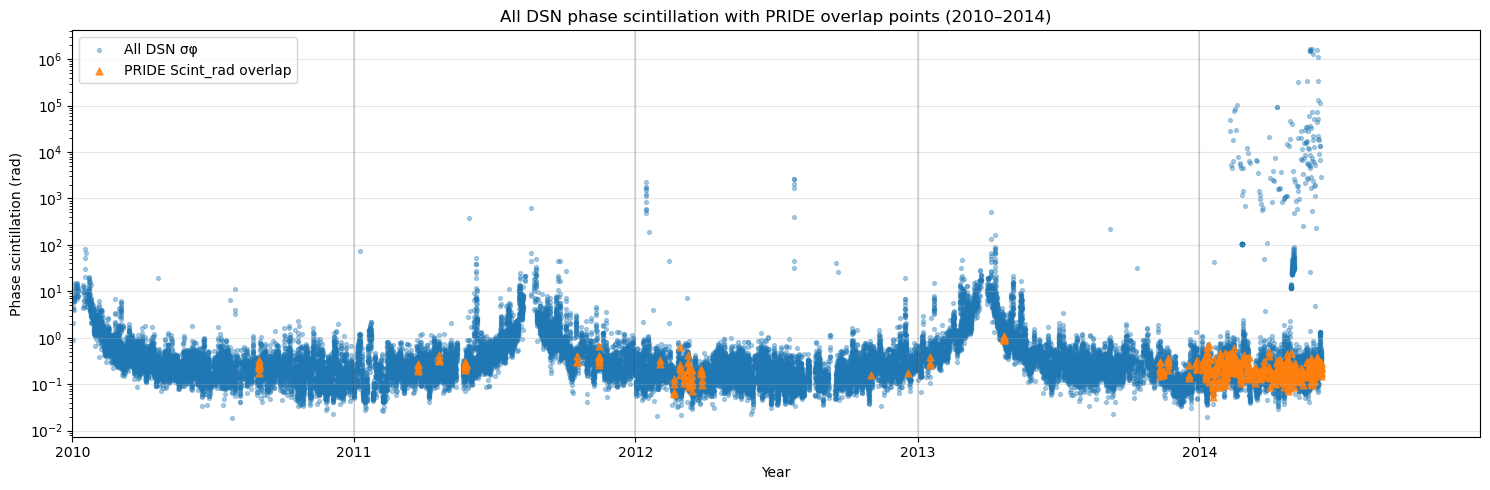

In [17]:
# ============================================================
# PLOT — All DSN data with PRIDE overlap points
# ============================================================

fig, ax = plt.subplots(figsize=(15, 5))

# All DSN bins
ax.scatter(
    dsn_all_df["utc_time"],
    dsn_all_df["dsn_sigma_phi_rad"],
    s=8,
    alpha=0.35,
    label="All DSN σφ",
)

# Optional: PRIDE overlap points from combined_df
if "combined_df" in globals() and "utc_time" in combined_df.columns:
    ax.scatter(
        combined_df["utc_time"],
        combined_df["pride_scint_rad"],
        s=24,
        alpha=0.8,
        marker="^",
        label="PRIDE Scint_rad overlap",
    )

ax.set_xlim(pd.Timestamp("2010-01-01"), pd.Timestamp("2014-12-31"))

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for yr in range(2010, 2015):
    ax.axvline(pd.Timestamp(f"{yr}-01-01"), color="black", alpha=0.12)

ax.set_yscale("log")
ax.set_xlabel("Year")
ax.set_ylabel("Phase scintillation (rad)")
ax.set_title("All DSN phase scintillation with PRIDE overlap points (2010–2014)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# SECTION — Load DSN/CACTus events from notebook 05
# ============================================================

EVENTS_FOR_PRIDE_FILE = OUTPUT_DIR / f"dsn_cactus_events_for_pride_{YEAR}.csv"

events_for_pride = pd.read_csv(
    EVENTS_FOR_PRIDE_FILE,
    parse_dates=[
        "start", "end", "mid",
        "matched_cactus_launch_utc",
    ],
)

supported_events = events_for_pride[
    (events_for_pride["cactus_crosses_p_point"] == True) &
    (events_for_pride["cactus_direction_consistent"] == True)
].copy()
if debug:
    print("Supported DSN/CACTus events:", len(supported_events))
    display(supported_events)

Supported DSN/CACTus events: 16


,event_id,year,start,end,mid,duration_hr,n_windows,peak_clean_signal,median_clean_signal,peak_phase_rms_rad,...,cactus_crosses_p_point,cactus_direction_consistent,matched_cactus_launch_utc,matched_cactus_speed_kms,matched_cactus_pa_deg,matched_cactus_width_deg,cactus_predicted_distance_AU,cactus_radial_error_AU,cactus_angle_error_deg,cactus_angle_allowed_deg
4,5,2013,2013-02-26 14:47:50,2013-02-26 15:27:50,2013-02-26 15:07:50,0.666667,3,7.545557,5.489893,40.051214,...,True,True,2013-02-26 09:36:00,702.0,290.0,286.0,0.093429,0.039072,58.000000,158.0
5,6,2013,2013-03-07 08:17:50,2013-03-07 08:57:50,2013-03-07 08:37:50,0.666667,3,6.060798,5.476701,40.037687,...,True,True,2013-03-06 09:24:00,281.0,13.0,24.0,0.157088,0.060618,18.571412,27.0
6,7,2013,2013-04-08 10:07:50,2013-04-08 10:37:50,2013-04-08 10:22:50,0.500000,2,3.792230,3.712104,84.428370,...,True,True,2013-04-07 07:12:00,231.0,21.0,28.0,0.151094,0.099392,1.456829,29.0
9,10,2013,2013-05-01 15:17:50,2013-05-01 15:47:50,2013-05-01 15:32:50,0.500000,2,5.006097,4.160105,45.391249,...,True,True,2013-05-01 03:12:00,492.0,79.0,124.0,0.146188,0.006303,53.748380,77.0
10,11,2013,2013-05-02 14:57:50,2013-05-02 15:37:50,2013-05-02 15:17:50,0.666667,3,4.262823,3.630766,17.858643,...,True,True,2013-05-01 13:48:00,330.0,60.0,38.0,0.202481,0.045550,12.977546,34.0
11,12,2013,2013-05-16 15:57:50,2013-05-16 16:37:50,2013-05-16 16:17:50,0.666667,3,6.436086,5.386200,11.968612,...,True,True,2013-05-14 16:36:00,143.0,32.0,10.0,0.164137,0.056012,1.240625,20.0
12,13,2013,2013-05-19 14:57:50,2013-05-19 15:27:50,2013-05-19 15:12:50,0.500000,2,4.640629,3.938102,10.179147,...,True,True,2013-05-14 16:36:00,143.0,32.0,10.0,0.408177,0.174717,10.000000,20.0
15,16,2013,2013-06-23 08:27:50,2013-06-23 08:57:50,2013-06-23 08:42:50,0.500000,2,3.624164,3.392571,1.642470,...,True,True,2013-06-17 12:36:00,135.0,34.0,6.0,0.455189,0.069095,12.000000,18.0
19,20,2013,2013-09-02 17:17:50,2013-09-02 17:47:50,2013-09-02 17:32:50,0.500000,2,3.110397,3.077418,1.857418,...,True,True,2013-08-30 08:00:00,339.0,10.0,14.0,0.665252,0.026699,10.065972,22.0
20,21,2013,2013-09-07 11:57:50,2013-09-07 12:37:50,2013-09-07 12:17:50,0.666667,3,3.416576,3.276167,4.310578,...,True,True,2013-09-04 13:25:00,390.0,48.0,90.0,0.665225,0.014230,22.628472,60.0


In [19]:
# ============================================================
# PRIDE coverage on DSN/CACTus event days
# ============================================================

EVENT_DAY_WINDOW_DAYS = 0      # same day only
BACKGROUND_DAYS = 2            # local background around event day

rows = []

plot_bins = binned_df.copy().sort_index()
plot_bins.index = pd.to_datetime(plot_bins.index)

events = supported_events.copy()
for c in ["start", "end", "mid"]:
    events[c] = pd.to_datetime(events[c])

for _, evt in events.iterrows():

    event_day = evt["mid"].normalize()

    # PRIDE on the DSN event day
    pride_day = plot_bins[
        plot_bins.index.normalize() == event_day
    ]

    # local background: ±2 days excluding event day
    bg_start = event_day - pd.Timedelta(days=BACKGROUND_DAYS)
    bg_end = event_day + pd.Timedelta(days=BACKGROUND_DAYS + 1)

    pride_bg = plot_bins[
        (plot_bins.index >= bg_start) &
        (plot_bins.index < bg_end) &
        (plot_bins.index.normalize() != event_day)
    ]

    day_med = pride_day["pride_scint_rad"].median()
    day_max = pride_day["pride_scint_rad"].max()
    bg_med = pride_bg["pride_scint_rad"].median()

    rows.append({
        "event_id": evt["event_id"],
        "event_day": event_day,
        "start": evt["start"],
        "end": evt["end"],
        "n_pride_day_bins": len(pride_day),
        "n_pride_bg_bins": len(pride_bg),
        "pride_day_median": day_med,
        "pride_day_max": day_max,
        "pride_bg_median": bg_med,
        "pride_day_ratio": day_med / bg_med if pd.notna(day_med) and pd.notna(bg_med) and bg_med > 0 else np.nan,
        "pride_peak_ratio": day_max / bg_med if pd.notna(day_max) and pd.notna(bg_med) and bg_med > 0 else np.nan,
        "dsn_peak_clean_signal": evt.get("peak_clean_signal", np.nan),
        "matched_cactus_launch_utc": evt.get("matched_cactus_launch_utc", pd.NaT),
    })

pride_day_response = pd.DataFrame(rows)
if debug:
    display(pride_day_response)
    
    print("Events with PRIDE same-day coverage:",
          (pride_day_response["n_pride_day_bins"] > 0).sum(),
          "of",
          len(pride_day_response))
    
    display(
        pride_day_response[
            pride_day_response["n_pride_day_bins"] > 0
        ].sort_values("pride_peak_ratio", ascending=False)
    )

,event_id,event_day,start,end,n_pride_day_bins,n_pride_bg_bins,pride_day_median,pride_day_max,pride_bg_median,pride_day_ratio,pride_peak_ratio,dsn_peak_clean_signal,matched_cactus_launch_utc
0,5,2013-02-26,2013-02-26 14:47:50,2013-02-26 15:27:50,0,0,NaN,NaN,NaN,NaN,NaN,7.545557,2013-02-26 09:36:00
1,6,2013-03-07,2013-03-07 08:17:50,2013-03-07 08:57:50,0,0,NaN,NaN,NaN,NaN,NaN,6.060798,2013-03-06 09:24:00
2,7,2013-04-08,2013-04-08 10:07:50,2013-04-08 10:37:50,0,0,NaN,NaN,NaN,NaN,NaN,3.792230,2013-04-07 07:12:00
3,10,2013-05-01,2013-05-01 15:17:50,2013-05-01 15:47:50,0,0,NaN,NaN,NaN,NaN,NaN,5.006097,2013-05-01 03:12:00
4,11,2013-05-02,2013-05-02 14:57:50,2013-05-02 15:37:50,0,0,NaN,NaN,NaN,NaN,NaN,4.262823,2013-05-01 13:48:00
5,12,2013-05-16,2013-05-16 15:57:50,2013-05-16 16:37:50,0,0,NaN,NaN,NaN,NaN,NaN,6.436086,2013-05-14 16:36:00
6,13,2013-05-19,2013-05-19 14:57:50,2013-05-19 15:27:50,0,0,NaN,NaN,NaN,NaN,NaN,4.640629,2013-05-14 16:36:00
7,16,2013-06-23,2013-06-23 08:27:50,2013-06-23 08:57:50,0,0,NaN,NaN,NaN,NaN,NaN,3.624164,2013-06-17 12:36:00
8,20,2013-09-02,2013-09-02 17:17:50,2013-09-02 17:47:50,0,0,NaN,NaN,NaN,NaN,NaN,3.110397,2013-08-30 08:00:00
9,21,2013-09-07,2013-09-07 11:57:50,2013-09-07 12:37:50,0,0,NaN,NaN,NaN,NaN,NaN,3.416576,2013-09-04 13:25:00


Events with PRIDE same-day coverage: 0 of 16


,event_id,event_day,start,end,n_pride_day_bins,n_pride_bg_bins,pride_day_median,pride_day_max,pride_bg_median,pride_day_ratio,pride_peak_ratio,dsn_peak_clean_signal,matched_cactus_launch_utc


In [21]:
"""
# ============================================================
# SECTION — Selectable PRIDE + DSN phase + raw DSN Doppler plot
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown

# Use only event days with PRIDE coverage
covered_days = pride_day_response[
    pride_day_response["n_pride_day_bins"] > 0
]["event_day"].dt.strftime("%Y-%m-%d").tolist()

if len(covered_days) == 0:
    raise ValueError("No DSN/CACTus event days have PRIDE coverage.")

# Make sure DSN raw dataframe exists
if "dsn_df" not in globals():
    raise KeyError("dsn_df not found. Load the raw DSN Doppler data first.")

# Convert raw Doppler Hz to mm/s for readability
F_CARRIER_HZ = 8.4e9
C_MPS = 299792458.0
HZ_TO_MM_S = (C_MPS / F_CARRIER_HZ) * 1000.0

dsn_raw = dsn_df.copy().sort_index()
dsn_raw.index = pd.to_datetime(dsn_raw.index)

if "doppler_mm_s" not in dsn_raw.columns:
    dsn_raw["doppler_mm_s"] = dsn_raw["doppler"] * HZ_TO_MM_S


def plot_pride_dsn_doppler_day(day_str):
    day = pd.to_datetime(day_str).normalize()

    day_events = supported_events[
        pd.to_datetime(supported_events["mid"]).dt.normalize() == day
    ].copy()

    day_bins = binned_df[
        pd.to_datetime(binned_df.index).normalize() == day
    ].copy()

    raw_day = dsn_raw[
        dsn_raw.index.normalize() == day
    ].copy()

    if day_bins.empty:
        print("No PRIDE/DSN binned data on this day.")
        return

    fig, axes = plt.subplots(
        3, 1,
        figsize=(11, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 1, 1.2]}
    )

    ax1, ax2, ax3 = axes

    # --------------------------------------------------------
    # Panel A — DSN phase scintillation
    # --------------------------------------------------------
    ax1.plot(
        day_bins.index,
        day_bins["dsn_sigma_phi_rad"],
        marker="o",
        linewidth=1.5,
        label="DSN σφ"
    )

    ax1.set_ylabel("DSN σφ (rad)")
    ax1.set_title(f"DSN/PRIDE comparison on {day.date()} ({YEAR})")
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc="best")

    # --------------------------------------------------------
    # Panel B — PRIDE scintillation
    # --------------------------------------------------------
    ax2.plot(
        day_bins.index,
        day_bins["pride_scint_rad"],
        marker="^",
        linestyle="--",
        linewidth=1.5,
        label="PRIDE Scint_rad"
    )

    ax2.set_ylabel("PRIDE (rad)")
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc="best")

    # --------------------------------------------------------
    # Panel C — Raw DSN Doppler
    # --------------------------------------------------------
    ax3.plot(
        raw_day.index,
        raw_day["doppler_mm_s"],
        linewidth=0.8,
        alpha=0.8,
        label="Raw DSN Doppler residual"
    )

    ax3.set_ylabel("Doppler residual\n(mm/s)")
    ax3.set_xlabel("UTC time")
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc="best")

    # --------------------------------------------------------
    # Shade DSN/CACTus event windows
    # --------------------------------------------------------
    for ax in axes:
        for j, (_, evt) in enumerate(day_events.iterrows()):
            ax.axvspan(
                evt["start"],
                evt["end"],
                alpha=0.2,
                label="DSN/CACTus event" if (ax is ax1 and j == 0) else None
            )

    # Avoid duplicate legends after shading
    ax1.legend(loc="best")

    plt.tight_layout()
    plt.show()


interact(
    plot_pride_dsn_doppler_day,
    day_str=Dropdown(
        options=covered_days,
        description="Event day:"
    )
);

"""

'\n# ============================================================\n# SECTION — Selectable PRIDE + DSN phase + raw DSN Doppler plot\n# ============================================================\n\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\nfrom ipywidgets import interact, Dropdown\n\n# Use only event days with PRIDE coverage\ncovered_days = pride_day_response[\n    pride_day_response["n_pride_day_bins"] > 0\n]["event_day"].dt.strftime("%Y-%m-%d").tolist()\n\nif len(covered_days) == 0:\n    raise ValueError("No DSN/CACTus event days have PRIDE coverage.")\n\n# Make sure DSN raw dataframe exists\nif "dsn_df" not in globals():\n    raise KeyError("dsn_df not found. Load the raw DSN Doppler data first.")\n\n# Convert raw Doppler Hz to mm/s for readability\nF_CARRIER_HZ = 8.4e9\nC_MPS = 299792458.0\nHZ_TO_MM_S = (C_MPS / F_CARRIER_HZ) * 1000.0\n\ndsn_raw = dsn_df.copy().sort_index()\ndsn_raw.index = pd.to_datetime(dsn_raw.index)\n\nif "doppler_mm_s" not in ds